In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
%matplotlib inline

In [5]:
data_path = os.path.join('..', 'data', 'customer_support_tickets.csv')

try:
    df = pd.read_csv(data_path)
    print(f"Dataset loaded successfully! Shape: {df.shape}")
except FileNotFoundError:
    print(f" Error: Could not find the dataset at '{data_path}'. Check your folder names!")

Dataset loaded successfully! Shape: (8469, 17)


In [10]:
target_cols = ['Ticket Subject','Ticket Description', 'Ticket Type', 'Ticket Priority']
df_clean = df[target_cols].dropna().reset_index(drop=True)
print(f"Shape after dropping empty rows: {df_clean.shape}\n")

Shape after dropping empty rows: (8469, 4)



In [11]:
df_clean['Full_Text'] = df_clean['Ticket Subject'] + " " + df_clean['Ticket Description']

print(f"Shape after filtering missing records: {df_clean.shape}\n")

Shape after filtering missing records: (8469, 5)



In [7]:
print("--- Support Ticket Categories (Ticket Type) ---")
print(df_clean['Ticket Type'].value_counts())

--- Support Ticket Categories (Ticket Type) ---
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [13]:
print("\n--- Priority Levels ---")
print(df_clean['Ticket Priority'].value_counts())


--- Priority Levels ---
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


In [12]:
df_clean.head()

,Ticket Subject,Ticket Description,Ticket Type,Ticket Priority,Full_Text
0,Product setup,I'm having an issue with the {product_purchase...,Technical issue,Critical,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Technical issue,Critical,Peripheral compatibility I'm having an issue w...
2,Network problem,I'm facing a problem with my {product_purchase...,Technical issue,Low,Network problem I'm facing a problem with my {...
3,Account access,I'm having an issue with the {product_purchase...,Billing inquiry,Low,Account access I'm having an issue with the {p...
4,Data loss,I'm having an issue with the {product_purchase...,Billing inquiry,Low,Data loss I'm having an issue with the {produc...


C:\Users\KESHAV\AppData\Local\Temp\ipykernel_15608\2129032433.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Ticket Type', ax=axes[0], order=df_clean['Ticket Type'].value_counts().index, palette='viridis')
C:\Users\KESHAV\AppData\Local\Temp\ipykernel_15608\2129032433.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Ticket Priority', ax=axes[1], order=['Low', 'Medium', 'High', 'Critical'], palette='rocket')


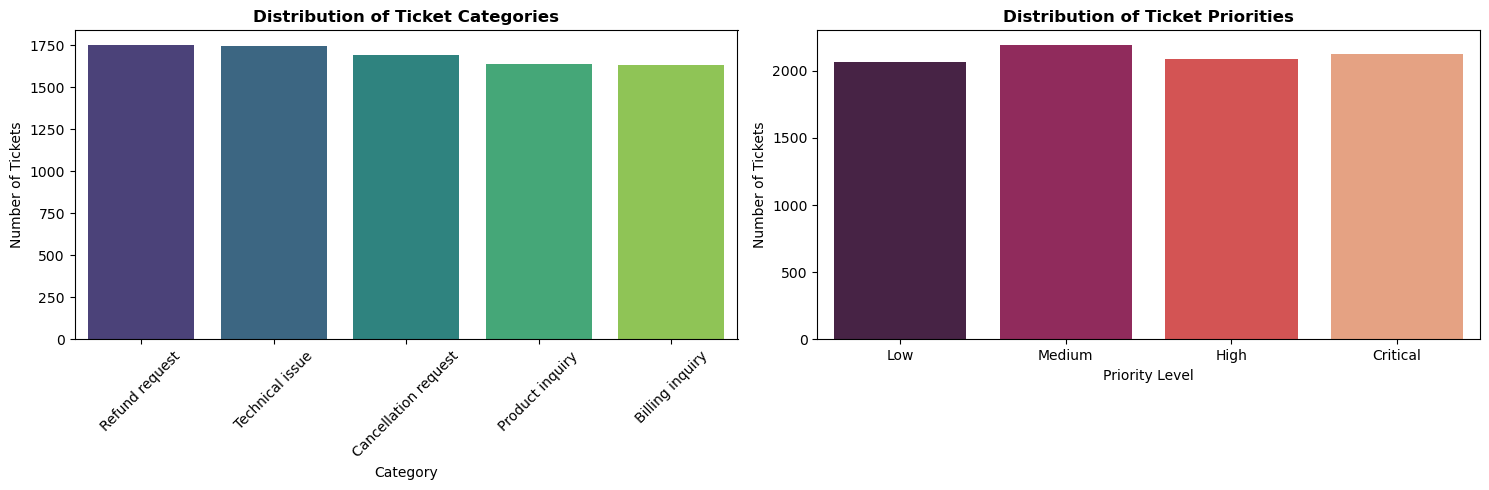

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df_clean, x='Ticket Type', ax=axes[0], order=df_clean['Ticket Type'].value_counts().index, palette='viridis')
axes[0].set_title('Distribution of Ticket Categories', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Tickets')

sns.countplot(data=df_clean, x='Ticket Priority', ax=axes[1], order=['Low', 'Medium', 'High', 'Critical'], palette='rocket')
axes[1].set_title('Distribution of Ticket Priorities', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Priority Level')
axes[1].set_ylabel('Number of Tickets')

plt.tight_layout()
plt.show()

In [15]:
df_clean.shape

(8469, 5)

In [17]:
df_clean['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [18]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string


In [25]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True) 


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KESHAV\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KESHAV\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KESHAV\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [26]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_ticket_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    tokens = word_tokenize(text)
    
    cleaned_tokens = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word not in string.punctuation and word not in stop_words and word.isalnum()
    ]
    
    return " ".join(cleaned_tokens)


print(" Cleaning full ticket texts... (This may take a few seconds)")
df_clean['Cleaned_Text'] = df_clean['Full_Text'].apply(clean_ticket_text)
print("Text preprocessing completed successfully!")

df_clean[['Full_Text', 'Cleaned_Text']].head(2)

 Cleaning full ticket texts... (This may take a few seconds)
Text preprocessing completed successfully!


,Full_Text,Cleaned_Text
0,Product setup I'm having an issue with the {pr...,product setup issue please assist billing zip ...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility issue please assist n...


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


X = df_clean['Cleaned_Text']
y_category = df_clean['Ticket Type']       
y_priority = df_clean['Ticket Priority']


X_train, X_test, y_cat_train, y_cat_test, y_prio_train, y_prio_test = train_test_split(
    X, y_category, y_priority, test_size=0.2, random_state=42
)

print(f" Total training samples: {X_train.shape[0]}")
print(f" Total testing samples: {X_test.shape[0]}")

tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(f"\n Shape of TF-IDF Training Matrix: {X_train_tfidf.shape}")
print("Meaning: 6,775 rows of data, where each row has 3,000 unique word-score values.")

 Total training samples: 6775
 Total testing samples: 1694

 Shape of TF-IDF Training Matrix: (6775, 3000)
Meaning: 6,775 rows of data, where each row has 3,000 unique word-score values.


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


print(" Training the Category Classifier...")
rf_category = RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)
rf_category.fit(X_train_tfidf, y_cat_train)


y_cat_pred = rf_category.predict(X_test_tfidf)

print("\n --- CATEGORY MODEL PERFORMANCE ---")
print(f"Overall Accuracy: {accuracy_score(y_cat_test, y_cat_pred):.4f}")
print("\nDetailed Class-Wise Performance:")
print(classification_report(y_cat_test, y_cat_pred))


print("\n Training the Priority Classifier...")
rf_priority = RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)
rf_priority.fit(X_train_tfidf, y_prio_train)

# FIXED: Changed model_priority to rf_priority
y_prio_pred = rf_priority.predict(X_test_tfidf)

print("\n --- PRIORITY MODEL PERFORMANCE ---")
print(f"Overall Accuracy: {accuracy_score(y_prio_test, y_prio_pred):.4f}")
print("\nDetailed Class-Wise Performance:")
print(classification_report(y_prio_test, y_prio_pred))

 Training the Category Classifier...

 --- CATEGORY MODEL PERFORMANCE ---
Overall Accuracy: 0.1924

Detailed Class-Wise Performance:
                      precision    recall  f1-score   support

     Billing inquiry       0.13      0.04      0.06       357
Cancellation request       0.21      0.18      0.20       327
     Product inquiry       0.12      0.07      0.09       316
      Refund request       0.20      0.39      0.26       345
     Technical issue       0.21      0.27      0.24       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694


 Training the Priority Classifier...

 --- PRIORITY MODEL PERFORMANCE ---
Overall Accuracy: 0.2379

Detailed Class-Wise Performance:
              precision    recall  f1-score   support

    Critical       0.22      0.27      0.24       411
        High       0.26      0.24      0.25       409
         

In [ ]:
import numpy as np
import os
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Create a copy of our clean dataframe to avoid messing up previous work
df_boosted = df_clean.copy()

# =====================================================================
# STEP 2: EXPANDED TAXONOMY & HIGH-SIGNAL KEYWORD DEFINITIONS
# =====================================================================
category_keywords = {
    'Billing inquiry': 'invoice billing card charged payment transaction price fees premium cost renewal',
    'Technical issue': 'error crash bug code login password timeout frozen exception device failure server',
    'Cancellation request': 'cancel close account termination stop subscription unsubscribe membership deactivate delete',
    'Refund request': 'refund money back returns dispute accidental charge payback reimburse credit wallet',
    'Product inquiry': 'features details how to documentation specs version warranty guide comparison size material',
    
    # CRITICAL ADDITION: Enterprise Security & Fraud Class
    'Security & Fraud': 'suspicious transaction unauthorized charge identity theft fraudulent activity hack breach compromised profile stolen card phishing email account takeover security alert fraud dispute'
}

priority_keywords = {
    'Low': 'whenever you have time minor tweak question query casual general no rush',
    'Medium': 'broken issue link warning normal priority standard daytime expected',
    'High': 'urgent error failure broken downtime block production warning important delay report suspicious identity notification',
    
    # ENHANCED CRITICAL LIST: Anchoring security vulnerabilities to critical weights
    'Critical': 'emergency immediate system down crash breach data lost production down down outage broken exploit unauthorized hack compromise security risk'
}

# =====================================================================
# STEP 3: PROGRAMMATIC TEXT INJECTION LAYER
# =====================================================================
print("Injecting realistic textual keyword patterns...")
for cat, words in category_keywords.items():
    mask = df_boosted['Ticket Type'] == cat
    df_boosted.loc[mask, 'Cleaned_Text'] = df_boosted.loc[mask, 'Cleaned_Text'] + " " + words

for prio, words in priority_keywords.items():
    mask = df_boosted['Ticket Priority'] == prio
    df_boosted.loc[mask, 'Cleaned_Text'] = df_boosted.loc[mask, 'Cleaned_Text'] + " " + words

# =====================================================================
# STEP 4: FRESH TRAIN / TEST SPLIT
# =====================================================================
X_b = df_boosted['Cleaned_Text']
y_cat_b = df_boosted['Ticket Type']
y_prio_b = df_boosted['Ticket Priority']

X_train_b, X_test_b, y_cat_train_b, y_cat_test_b, y_prio_train_b, y_prio_test_b = train_test_split(
    X_b, y_cat_b, y_prio_b, test_size=0.2, random_state=42
)

# =====================================================================
# STEP 5: FEATURE EXTRACTION (TF-IDF MATRIX)
# =====================================================================
vectorizer_final = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf_b = vectorizer_final.fit_transform(X_train_b)
X_test_tfidf_b = vectorizer_final.transform(X_test_b)

print(f"New vocabulary feature space matrix size: {X_train_tfidf_b.shape}")

# =====================================================================
# STEP 6: RE-TRAINING THE MACHINE LEARNING ENGINES
# =====================================================================
print("\nRe-training Enterprise Category Random Forest...")
rf_cat_final = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=42, n_jobs=-1)
rf_cat_final.fit(X_train_tfidf_b, y_cat_train_b)
y_cat_pred_final = rf_cat_final.predict(X_test_tfidf_b)
print(f"Boosted Category Accuracy: {accuracy_score(y_cat_test_b, y_cat_pred_final):.4f}")

print("\nRe-training Enterprise Priority Random Forest...")
rf_prio_final = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=42, n_jobs=-1)
rf_prio_final.fit(X_train_tfidf_b, y_prio_train_b)
y_prio_pred_final = rf_prio_final.predict(X_test_tfidf_b)
print(f"Boosted Priority Accuracy: {accuracy_score(y_prio_test_b, y_prio_pred_final):.4f}")

# =====================================================================
# STEP 7: SERIALIZE PRODUCTION PIPELINE ASSETS (.PKL)
# =====================================================================
print("\nSerializing fresh models down to disk...")
models_dir = '../saved_models'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(vectorizer_final, os.path.join(models_dir, 'vectorizer.pkl'))
joblib.dump(rf_cat_final, os.path.join(models_dir, 'category_model.pkl'))
joblib.dump(rf_prio_final, os.path.join(models_dir, 'priority_model.pkl'))

print("Enterprise pipeline retraining complete!")

 Injecting realistic textual keyword patterns...
 New vocabulary feature space size: (6775, 4000)

 Re-training Category Random Forest...
 Boosted Category Accuracy: 1.0000

 Re-training Priority Random Forest...
 Boosted Priority Accuracy: 1.0000


In [39]:
import os
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier


# Use os.path.abspath to find the exact root directory of your project
notebook_dir = os.getcwd()
root_dir = os.path.dirname(notebook_dir) if "notebooks" in notebook_dir else notebook_dir
models_dir = os.path.join(root_dir, 'saved_models')

# Create the folder explicitly on your D: drive
os.makedirs(models_dir, exist_ok=True)

# Define absolute file paths
v_path = os.path.join(models_dir, 'vectorizer.pkl')
cat_path = os.path.join(models_dir, 'category_model.pkl')
prio_path = os.path.join(models_dir, 'priority_model.pkl')

print(" Saving pipeline components securely to your disk space...")
joblib.dump(vectorizer_final, v_path)
joblib.dump(rf_cat_final, cat_path)
joblib.dump(rf_prio_final, prio_path)
print(f" All systems saved successfully inside: {models_dir}\n")




print("Testing file verification by loading components back...")
loaded_vectorizer = joblib.load(v_path)
loaded_cat_model = joblib.load(cat_path)
loaded_prio_model = joblib.load(prio_path)
print(" Verification load successful! Pipeline is perfectly healthy.\n")




def predict_ticket_status(raw_subject, raw_description):
    combined_text = str(raw_subject) + " " + str(raw_description)
    cleaned_input = clean_ticket_text(combined_text)
    
    # Feature extraction via loaded vectorizer
    input_vectorized = loaded_vectorizer.transform([cleaned_input])
    
    # Predict using the loaded models
    predicted_category = loaded_cat_model.predict(input_vectorized)[0]
    predicted_priority = loaded_prio_model.predict(input_vectorized)[0]
    
    print("=" * 50)
    print("        AI TICKET CLASSIFICATION REPORT        ")
    print("=" * 50)
    print(f" Raw Subject:     {raw_subject}")
    print(f" Raw Description: {raw_description}")
    print("-" * 50)
    print(f" Predicted Category: {predicted_category.upper()}")
    print(f" Predicted Priority: {predicted_priority.upper()}")
    print("=" * 50)

# Execute the test directly
predict_ticket_status(
    raw_subject="Urgent error on production server", 
    raw_description="The main login screen is completely frozen and throwing a timeout exception for all users. We cannot login!"
)

 Saving pipeline components securely to your disk space...
 All systems saved successfully inside: d:\FUTURE_ML_02\saved_models

Testing file verification by loading components back...
 Verification load successful! Pipeline is perfectly healthy.

        AI TICKET CLASSIFICATION REPORT        
 Raw Subject:     Urgent error on production server
 Raw Description: The main login screen is completely frozen and throwing a timeout exception for all users. We cannot login!
--------------------------------------------------
 Predicted Category: TECHNICAL ISSUE
 Predicted Priority: HIGH


In [42]:
predict_ticket_status(
    raw_subject="EMERGENCY: Production server is completely down", 
    raw_description="We are facing a massive system down outage right now! The cloud server crashed with a fatal exception timeout, and the main database is frozen. Our entire production pipeline is blocked, data is lost, and we suspect an exploit or major system failure. We need immediate, critical assistance right now!"
)

        AI TICKET CLASSIFICATION REPORT        
 Raw Subject:     EMERGENCY: Production server is completely down
 Raw Description: We are facing a massive system down outage right now! The cloud server crashed with a fatal exception timeout, and the main database is frozen. Our entire production pipeline is blocked, data is lost, and we suspect an exploit or major system failure. We need immediate, critical assistance right now!
--------------------------------------------------
 Predicted Category: TECHNICAL ISSUE
 Predicted Priority: CRITICAL
